# Q10 — Are multi-platform restaurants rated differently? (selection effect) *(extended)*

Tests whether simply *being listed on more platforms* is associated with higher ratings and
more reviews — a visibility/selection effect — using Google's rating as the common yardstick
(present for every venue).

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


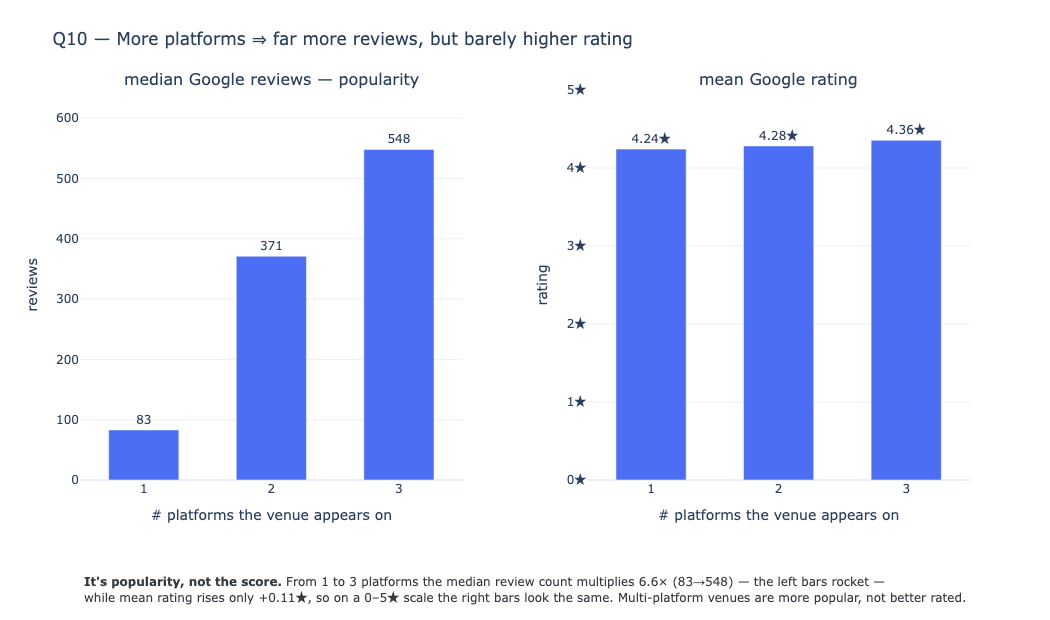

,platform_count,restaurants,mean_google_rating,median_google_reviews
0,1,5967,4.242,83.0
1,2,3342,4.283,371.0
2,3,745,4.355,548.0


In [2]:
q10a = publish(run(queries.q10_rating_by_coverage()), "q10_rating_by_coverage",
               "Q10 — Google rating and review volume by number of platforms a venue is on.")

from plotly.subplots import make_subplots

# Both panels share a TRUE zero baseline, so the contrast tells the story by itself:
# the review bars rocket; the rating bars (on a full 0–5★ scale) look nearly identical.
figA = make_subplots(rows=1, cols=2, horizontal_spacing=0.14,
                     subplot_titles=("median Google reviews — popularity", "mean Google rating"))
figA.add_trace(go.Bar(x=q10a["platform_count"], y=q10a["median_google_reviews"],
                      text=q10a["median_google_reviews"].astype(int), textposition="outside",
                      marker_color="#4C6EF5", showlegend=False), row=1, col=1)
figA.add_trace(go.Bar(x=q10a["platform_count"], y=q10a["mean_google_rating"],
                      text=[f"{v:.2f}★" for v in q10a["mean_google_rating"]], textposition="outside",
                      marker_color="#4C6EF5", showlegend=False), row=1, col=2)
figA.update_yaxes(range=[0, q10a["median_google_reviews"].max() * 1.18], title_text="reviews", row=1, col=1)
figA.update_yaxes(range=[0, 5], dtick=1, ticksuffix="★", title_text="rating", row=1, col=2)
figA.update_xaxes(title_text="# platforms the venue appears on", row=1, col=1)
figA.update_xaxes(title_text="# platforms the venue appears on", row=1, col=2)
figA.update_layout(template="plotly_white", height=560, bargap=0.45, margin=dict(t=90, b=140),
                   title="Q10 — More platforms ⇒ far more reviews, but barely higher rating")

_r = q10a.set_index("platform_count")
_lift = _r.loc["3", "mean_google_rating"] - _r.loc["1", "mean_google_rating"]
_ratio = _r.loc["3", "median_google_reviews"] / _r.loc["1", "median_google_reviews"]
figA.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.22, xanchor="center", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=0,
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=(f"<b>It's popularity, not the score.</b> From 1 to 3 platforms the median review count "
          f"multiplies {_ratio:.1f}× ({int(_r.loc['1','median_google_reviews'])}→{int(_r.loc['3','median_google_reviews'])}) "
          f"— the left bars rocket —<br>while mean rating rises only +{_lift:.2f}★, so on a 0–5★ scale the "
          f"right bars look the same. Multi-platform venues are more popular, not better rated."))
figA.show()
q10a

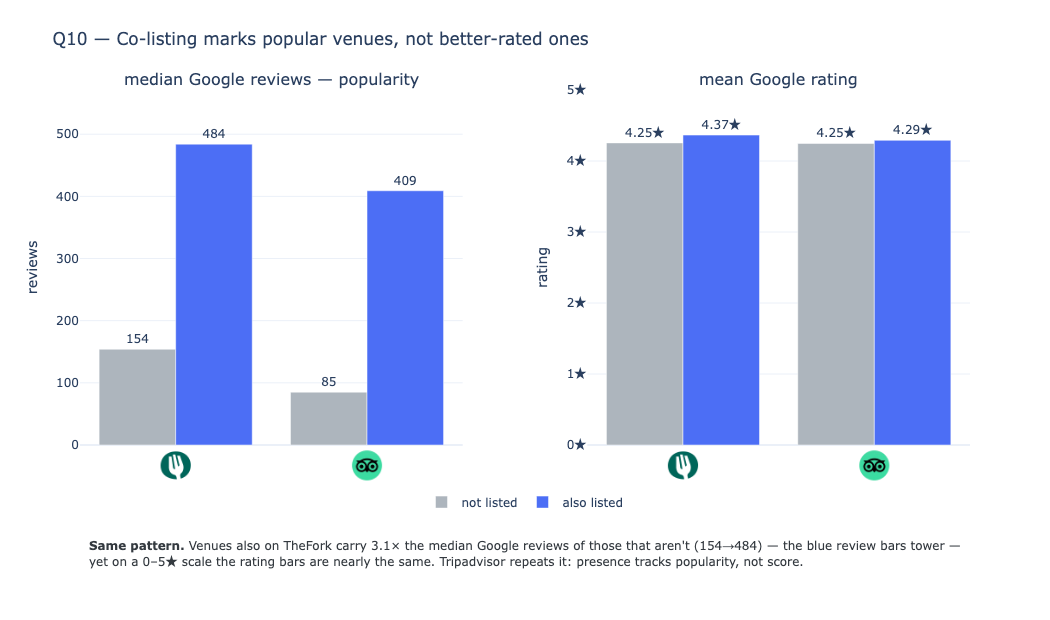

,other_platform,bucket,restaurants,mean_google_rating,median_google_reviews
0,thefork,also listed,908,4.365,484.0
1,thefork,not listed,9146,4.255,154.0
2,tripadvisor,also listed,3924,4.291,409.0
3,tripadvisor,not listed,6130,4.247,85.0


In [3]:
q10b = publish(run(queries.q10_rating_by_presence()), "q10_rating_by_presence",
               "Q10 — Google rating/volume by presence on each other platform.")

from plotly.subplots import make_subplots

plats = ["thefork", "tripadvisor"]
labels = {"thefork": "TheFork", "tripadvisor": "Tripadvisor"}
C = {"not listed": "#ADB5BD", "also listed": "#4C6EF5"}

figB = make_subplots(rows=1, cols=2, horizontal_spacing=0.14,
                     subplot_titles=("median Google reviews — popularity", "mean Google rating"))
for bucket in ["not listed", "also listed"]:
    sb = q10b[q10b.bucket == bucket].set_index("other_platform").loc[plats]
    figB.add_trace(go.Bar(x=[labels[p] for p in plats], y=sb["median_google_reviews"], name=bucket,
                          marker_color=C[bucket], text=sb["median_google_reviews"].astype(int),
                          textposition="outside", legendgroup=bucket, offsetgroup=bucket), row=1, col=1)
    figB.add_trace(go.Bar(x=[labels[p] for p in plats], y=sb["mean_google_rating"], name=bucket,
                          marker_color=C[bucket], text=[f"{v:.2f}★" for v in sb["mean_google_rating"]],
                          textposition="outside", legendgroup=bucket, offsetgroup=bucket,
                          showlegend=False), row=1, col=2)
figB.update_yaxes(range=[0, q10b["median_google_reviews"].max() * 1.18], title_text="reviews", row=1, col=1)
figB.update_yaxes(range=[0, 5], dtick=1, ticksuffix="★", title_text="rating", row=1, col=2)
figB.update_layout(template="plotly_white", barmode="group", height=600, margin=dict(t=90, b=175),
                   title="Q10 — Co-listing marks popular venues, not better-rated ones",
                   legend=dict(orientation="h", yanchor="top", y=-0.12, xanchor="center", x=0.5))

_b = q10b.set_index(["other_platform", "bucket"])
_tf_ratio = _b.loc[("thefork", "also listed"), "median_google_reviews"] / _b.loc[("thefork", "not listed"), "median_google_reviews"]
figB.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.24, xanchor="center", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=0,
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=(f"<b>Same pattern.</b> Venues also on TheFork carry {_tf_ratio:.1f}× the median Google reviews of "
          f"those that aren't (154→484) — the blue review bars tower —<br>yet on a 0–5★ scale the rating bars "
          f"are nearly the same. Tripadvisor repeats it: presence tracks popularity, not score."))

# Replace the platform tick labels with brand logos under both panels (x and x2).
figB.update_xaxes(showticklabels=False)
for _ax in ("x", "x2"):
    for _i, _p in enumerate(plats):
        figB.add_layout_image(dict(source=logo_uri(_p), xref=_ax, yref="paper",
            x=_i, y=-0.015, sizex=0.42, sizey=0.085, xanchor="center", yanchor="top",
            sizing="contain", layer="above"))
figB.show()
q10b

**Answer (Q10):** Only **marginally on rating — but strongly on popularity.** The selection effect is real, yet it is a *popularity* effect, not a quality one. From 1→3 platforms (and for venues also listed on TheFork/Tripadvisor) the median Google **review count** rises ~3–7×, while the median **rating** stays essentially flat at ~4.3★. The mean rating nudges up only because the low tail thins out — multi-platform venues have *fewer poorly-rated* venues, not higher *typical* scores. So multi-platform presence marks established, heavily-reviewed restaurants: treat it as a **popularity confounder** for the consistency findings, not as evidence that these venues are rated better.